# 이미지분석 (Image Analysis) — OpenCV 활용

---

## 1. 컬러 영상 (RGB, 3차원)

- 컬러 영상은 **R(빨강), G(초록), B(파랑)** 세 가지 채널로 구성된 3차원 데이터로 표현된다.
- 각 픽셀은 `(R, G, B)` 형태의 3개 값으로 색을 정의한다.
  - 예)  
    - (1, 0, 0) = Red  
    - (0, 1, 0) = Green  
    - (0, 0, 1) = Blue  
    - (1, 1, 1) = White  
    - (0, 0, 0) = Black  

- RGB 공간은 **3차원 좌표계(RGB Cube)** 로 표현 가능하며,  
  R·G·B 값의 조합에 따라 다양한 색상이 생성된다.

---

### RGB 채널 분리 예시

- 컬러 이미지는 **R, G, B 세 채널의 2차원 행렬로 분리 가능**
- 각 채널은 다음과 같이 표현된다.

$$
f_r(i,j), f_g(i,j), f_b(i,j), \quad 0 \le i < N, \ 0 \le j < M
$$

- 원본 이미지 → RGB 분리 후 각각의 단일 채널 영상(`f_r`, `f_g`, `f_b`)으로 표현 가능.

---

## 2. 영상처리 (Image Processing)

> 디지털 영상을 **수정(modification)** 및 **조작(manipulation)** 하여  
> 사용자가 원하는 결과를 얻는 기술적 과정

### 주요 목적
- 영상을 더 높은 품질로 개선  
- 특정 특징(윤곽, 명암 등)을 강조  
- 다른 영상 일부를 합성하여 새로운 영상 생성  
- 손상된 영상을 복원  

---

### 영상 처리 기술의 주요 사례

| 구분 | 설명 |
|:--|:--|
| **영상 개선 (평활화)** | 노이즈 제거, 명암 대비 향상 |
| **영상 복원** | 손상된 영상의 품질 복원 |
| **영상 변환** | 이산 코사인 변환(DCT) 등 주파수 영역 변환 |
| **영상 인식** | 지문, 얼굴 등 패턴 인식 |
| **영상 압축** | JPEG 등 손실/무손실 압축 |
| **영상 분석** | 윤곽선 검출, 엣지 추출 등 |

---

## 3. 컴퓨터 비전 (Computer Vision)

- **영상처리보다 포괄적인 개념**  
- 영상으로부터 의미 있는 정보를 추출하는 기술

### 관계
> 영상처리 → 영상을 조작하는 기술  
> 컴퓨터비전 → 영상에서 의미를 **이해하는 기술**

### 세부 영역
| 구분 | 설명 |
|:--|:--|
| **객체 인식 (Object Recognition)** | 영상 속 객체가 무엇인지 인식 |
| **객체 검출 (Object Detection)** | 객체의 위치를 찾는 기술 |
| **객체 추적 (Object Tracking)** | 움직이는 객체의 이동 경로를 추적 |

---

## 4. OpenCV 소개

- **Open Source Computer Vision Library**
- 이미지처리 및 컴퓨터 비전 분야의 대표적인 라이브러리

### 주요 기능
- 이미지 파일 읽기/쓰기 (`cv2.imread()`, `cv2.imwrite()`)
- 비디오 캡처 및 저장
- 이미지 필터링, 변환, 색공간 변환
- 얼굴, 눈, 자동차 등 객체 인식
- ML/DL 프레임워크(TensorFlow, PyTorch 등)와 연동 가능

---

## 5. OpenCV 주요 함수 정리

| 함수 | 기능 | 함수 | 기능 |
|:--|:--|:--|:--|
| `cv2.imread()` | 이미지 읽기 | `cv2.imwrite()` | 이미지 저장 |
| `cv2.cvtColor()` | 색상 공간 변환 | `cv2.line()` | 직선 그리기 |
| `cv2.resize()` | 이미지 크기 변경 | `cv2.rectangle()` | 사각형 그리기 |
| `cv2.imshow()` | 이미지 출력 | `cv2.circle()` | 원 그리기 |
| `cv2.putText()` | 텍스트 삽입 | `cv2.ellipse()` | 타원 그리기 |
| `cv2.split()` | 채널 분리 | `cv2.normalize()` | 픽셀 값 범위 조정 |
| `cv2.merge()` | 채널 병합 |  |  |

---

## 6. 얼굴 인식 (OpenCV)

### (1) Haar-like 특징 기반 얼굴 인식
- 모든 사람의 얼굴에는 **눈·코·입 주변의 공통된 밝기 패턴** 존재
- 이를 수학적으로 표현한 **Haar-like Feature** 사용

#### 3가지 기본 특징
- A, B: Two-rectangle feature  
- C: Three-rectangle feature  
- D: Four-rectangle feature  

→ 검정/흰색 부분의 **밝기 차이(임계값 이상)** 로 얼굴 여부 판단  
→ Sliding Window로 전체 이미지 탐색

#### 단점
- 영상의밝기값을이용하기때문에조명, 대조비에많이영향
- sample의 양이나질에따라성능에크게영향

---

### (2) Cascade 방식

- Haar 특징을 **단계별로 빠르게 적용하는 분류기 구조**
- 얼굴이 있을 법한 영역만 효율적으로 탐색

#### 작동 원리
1. 초기에 간단한 특징(적은 수의 분류기)으로 빠르게 거름  
2. 실패 시 즉시 중단하고 다음 영역으로 이동  
3. 통과하면 다음 단계의 더 복잡한 분류기를 적용  
→ 단계별 Cascade 구조로 효율적인 검출 수행

#### 특징
- 얼굴의 일부(눈, 코 등) 영역만을 학습하여 전체 얼굴 검출  
- 불필요한 연산을 최소화하여 실시간 검출 가능

---

## 7. 정리 요약

| 구분 | 설명 |
|:--|:--|
| **RGB 영상** | R/G/B 세 채널로 구성된 3차원 영상 |
| **영상처리** | 영상의 품질을 조정하거나 정보 추출을 위한 조작 |
| **컴퓨터비전** | 영상에서 의미 있는 정보 추출 |
| **OpenCV** | 이미지/영상처리 및 비전 기능 제공 오픈소스 라이브러리 |
| **Haar + Cascade** | OpenCV에서 사용하는 얼굴 검출 알고리즘 |

---

> 💡 **핵심 포인트:**  
> 영상처리는 "이미지를 바꾸는 기술",  
> 컴퓨터비전은 "이미지에서 의미를 읽는 기술"이다.  
> OpenCV는 이 둘을 모두 지원하는 강력한 도구이다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install opencv-python

In [3]:
import cv2

!curl -L https://www.dropbox.com/s/v4225z25x0zz4y3/pool.jpg -o pool.jpg

In [9]:
img = cv2.imread("pool.jpg")
type(img), img

(numpy.ndarray,
 array([[[ 87,  86,  76],
         [ 87,  86,  76],
         [ 88,  88,  76],
         ...,
         [255, 254, 253],
         [255, 254, 253],
         [255, 254, 253]],
 
        [[ 87,  86,  76],
         [ 87,  86,  76],
         [ 88,  88,  76],
         ...,
         [255, 254, 253],
         [255, 254, 253],
         [255, 254, 253]],
 
        [[ 87,  86,  76],
         [ 87,  86,  76],
         [ 87,  87,  75],
         ...,
         [255, 254, 253],
         [255, 254, 253],
         [255, 254, 253]],
 
        ...,
 
        [[ 73,  80,  89],
         [ 72,  79,  88],
         [ 72,  79,  88],
         ...,
         [204, 180, 104],
         [204, 180, 104],
         [204, 180, 104]],
 
        [[ 72,  79,  88],
         [ 72,  79,  88],
         [ 72,  79,  88],
         ...,
         [204, 180, 104],
         [203, 179, 103],
         [203, 179, 103]],
 
        [[ 72,  79,  88],
         [ 72,  79,  88],
         [ 72,  79,  88],
         ...,
         [20

In [10]:
img.shape

(3024, 4032, 3)

In [11]:
img.min(), img.max()

(np.uint8(0), np.uint8(255))

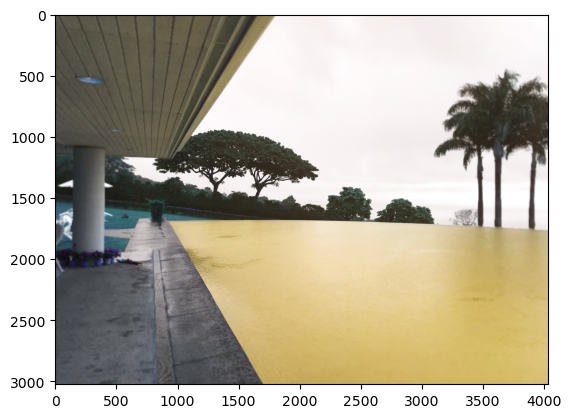

In [12]:
plt.imshow(img) ## RGB로 안되어 있어 색상이 다름(기본BGR)

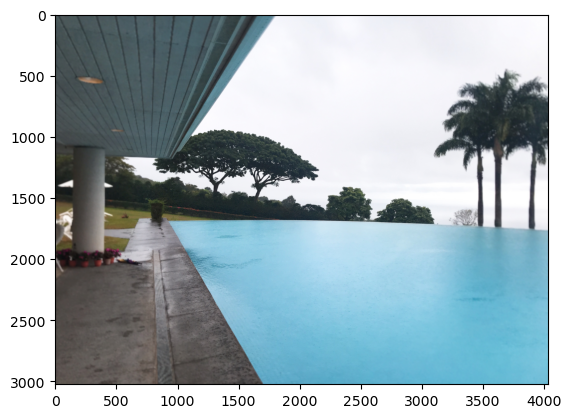

In [14]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("on")
plt.show()